## Дифференцируемая растеризация

Необходимо реализовать процедуру оптимизации текстуры из входных изображений с позами камер, считая что сэмплированная текстура и есть результат шейдинга.

In [ ]:
!pip install git+https://github.com/NVlabs/nvdiffrast.git --no-cache-dir --no-build-isolation
!pip install ninja xatlas trimesh torch matplotlib

  Cloning https://github.com/NVlabs/nvdiffrast.git to /tmp/pip-req-build-ryim7upt
  Running command git clone --filter=blob:none --quiet https://github.com/NVlabs/nvdiffrast.git /tmp/pip-req-build-ryim7upt
  Resolved https://github.com/NVlabs/nvdiffrast.git to commit 253ac4fcea7de5f396371124af597e6cc957bfae
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.0/261.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [21]:
%%bash

# Download dataset and helper library
for part in data lib; do
    if [ ! -d "${part}/" ]; then
        curl -sO "https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/differentiable-rasterization/${part}.zip"
        unzip -qo "${part}.zip"
    fi
done

# Install required dependencies
if ! pip freeze | grep -q nvdiffrast; then
    pip install -q \
        git+https://github.com/NVlabs/nvdiffrast.git \
        ninja xatlas trimesh \
        torch matplotlib
fi

In [22]:
import matplotlib.pyplot as plt
import nvdiffrast.torch as dr
import torch
import torch.nn.functional as Func

glctx = dr.RasterizeCudaContext()

In [23]:
from lib.dataset import DatasetNERF

dataset = DatasetNERF(cfg="./data/hotdog/transforms_train.json", resolution=(400, 400))

In [25]:
def render_textured(
    mesh,
    mvp,
    resolution=(800, 800),
    texture=None,
    enable_mip=True,
    max_mip_level=9,
):
    device = 'cuda'

    # Vertex processing
    v = mesh.verts.to(device)
    pos_w = torch.cat([v, torch.ones([v.shape[0], 1], device=device)], dim=1)

    mvp_gpu = mvp.to(device)
    if mvp_gpu.ndim == 3:
        mvp_gpu = mvp_gpu.squeeze(0)

    pos_clip = (pos_w @ mvp_gpu.t())[None, ...]

    # Rasterization
    f = mesh.faces.to(device).int()
    rast_out, rast_out_db = dr.rasterize(glctx, pos_clip, f, resolution=resolution)

    # Interpolate UV
    uv = mesh.uvs.to(device)

    if texture is not None and enable_mip:
        texc, texc_db = dr.interpolate(
            uv[None, ...], rast_out, f,
            rast_db=rast_out_db, diff_attrs='all'
        )
    else:
        texc, _ = dr.interpolate(uv[None, ...], rast_out, f)

    # Texture sampling
    if texture is not None:
        tex = texture[None, ...] if texture.ndim == 3 else texture

        if enable_mip:
            color = dr.texture(
                tex, texc,
                uv_da=texc_db,
                filter_mode='linear-mipmap-linear',
                max_mip_level=max_mip_level
            )
        else:
            color = dr.texture(tex, texc, filter_mode='linear')
    else:
        color = torch.cat([
            rast_out[..., 0:2],
            torch.ones_like(rast_out[..., 0:1])
        ], dim=-1)

    # Antialias and mask
    color = dr.antialias(color, rast_out, pos_clip, f)
    mask = (rast_out[..., -1:] > 0).float()

    return color * mask, mask

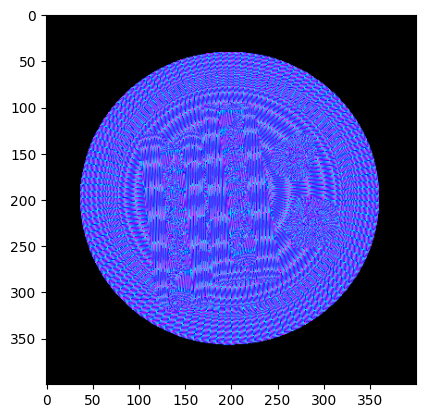

In [26]:
c, _ = render_textured(
    dataset.mesh,
    dataset[0]["mvp"],
    dataset.resolution,
)
plt.imshow(c[0].detach().cpu());

In [27]:
texture = torch.full([512, 512, 3], 0.5, device="cuda", requires_grad=True)
optimizer = torch.optim.Adam([texture], lr=1e-3)

In [28]:
# Цикл Оптимизации текстуры

for iteration in range(1000):
    optimizer.zero_grad()
    total_loss = 0

    # Проход по всем изображениям в датасете
    for idx in range(len(dataset)):
        sample = dataset[idx]
        target_image = sample["img"].to("cuda")

        if target_image.ndim == 4:
            target_image = target_image.squeeze(0)

        # Рендерим с текущей текстурой
        rendered, _ = render_textured(
            dataset.mesh,
            sample["mvp"],
            dataset.resolution,
            texture=texture,
            enable_mip=True,
            max_mip_level=9
        )

        # MSE loss между рендером и целевым изображением
        loss = Func.mse_loss(rendered[0], target_image)
        total_loss += loss

    # Backward pass
    total_loss = total_loss / len(dataset)
    total_loss.backward()
    optimizer.step()

    # Ограничиваем значения текстуры
    with torch.no_grad():
        texture.clamp_(0.0, 1.0)

    if (iteration + 1) % 100 == 0:
        print(f"Iter {iteration + 1}, Loss: {total_loss.item():.6f}")

Iter 100, Loss: 0.024994
Iter 200, Loss: 0.014276
Iter 300, Loss: 0.008010
Iter 400, Loss: 0.004542
Iter 500, Loss: 0.002734
Iter 600, Loss: 0.001848
Iter 700, Loss: 0.001438
Iter 800, Loss: 0.001260
Iter 900, Loss: 0.001186
Iter 1000, Loss: 0.001156


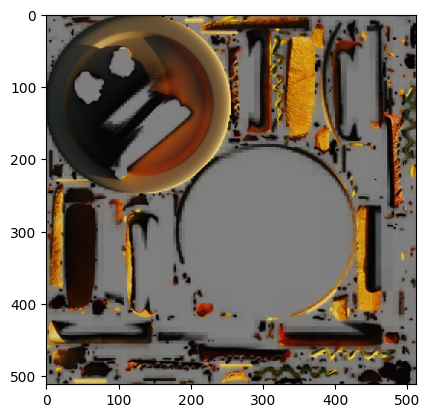

In [29]:
plt.imshow(texture.detach().cpu());

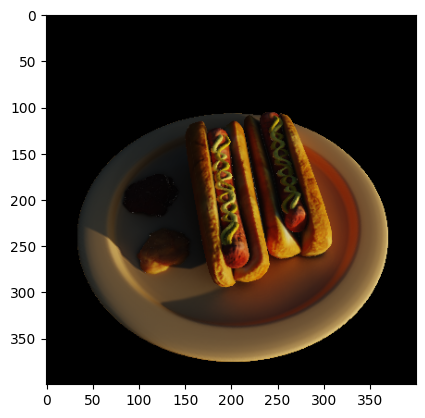

In [30]:
c, _ = render_textured(
    dataset.mesh,
    dataset[90]["mvp"],
    dataset.resolution,
    texture=texture,
)
plt.imshow(c[0].detach().cpu());